# 01 — Basic workflow: WoE logistic on UCI German Credit

This notebook walks through a credit-scoring fit end-to-end with
`model_crafter`. It mirrors the shape of the DESIGN.md §10 reference
example: spec → solve → assumptions → performance, with WoE-encoded
features and an L2-penalised logistic regression.

We use the [UCI German Credit](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data))
dataset (1,000 applicants, 20 features, binary default flag). The raw
file lives in `data/raw/german.data` and is loaded via the small
`_german.py` helper next to this notebook.

## 1. Load and inspect the data

In [1]:
import sys
from pathlib import Path

# Add this notebook's directory to sys.path so we can import _german.
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import model_crafter as mc
import _german

df = _german.load_german()
print(f"n = {len(df):,}    default rate = {df['default'].mean():.1%}")
df.head()

n = 1,000    default rate = 30.0%


,checking_status,duration_months,credit_history,purpose,credit_amount,savings,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age_years,other_installment_plans,housing,n_existing_credits,job,n_dependents,telephone,foreign_worker,default
0,<0DM,6,critical,radio_tv,1169,unknown,>=7yr,4,male_single,none,...,real_estate,67,none,own,2,skilled,1,registered,yes,0
1,0-200DM,48,paid_so_far,radio_tv,5951,<100DM,1-4yr,2,female_div_mar,none,...,real_estate,22,none,own,1,skilled,1,none,yes,1
2,no_account,12,critical,education,2096,<100DM,4-7yr,2,male_single,none,...,real_estate,49,none,own,1,unskilled_resident,2,none,yes,0
3,<0DM,42,paid_so_far,furniture,7882,<100DM,4-7yr,2,male_single,guarantor,...,building_society,45,none,free,1,skilled,2,none,yes,0
4,<0DM,24,delays_in_past,car_new,4870,<100DM,1-4yr,3,male_single,none,...,none,53,none,free,2,skilled,2,none,yes,1


## 2. Train / test split

We split 70 / 30 randomly (no time column in this dataset; notebook 02
demonstrates the temporal API on a synthetic origination date).

In [2]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(df))
n_train = int(0.7 * len(df))
train = df.iloc[idx[:n_train]].reset_index(drop=True)
test  = df.iloc[idx[n_train:]].reset_index(drop=True)
print(f"train: {len(train):,}    test: {len(test):,}")
print(f"train default rate: {train['default'].mean():.1%}")
print(f"test  default rate: {test['default'].mean():.1%}")

train: 700    test: 300
train default rate: 28.9%
test  default rate: 32.7%


## 3. Spec: a WoE-encoded logistic regression

`mc.woe(col, bins=...)` produces a single column whose value is the
bin's WoE; the joint logistic regression learns one global coefficient
per WoE term. Three binning strategies cover most cases:

* `mc.monotonic(...)` — supervised monotonic binning for numeric
  features (Siddiqi 2006 ch. 6).
* `mc.tree_bins(...)` — greedy single-feature CART for numeric features.
* `mc.categorical(group_rare=...)` — one bin per level, with rare
  levels folded into a `RARE` bucket.

We use monotonic binning for the numeric features and categorical
binning for the labelled ones; `group_rare` is set per-column to fold
tiny levels. `penalty=mc.l2(...)` keeps the joint fit identifiable
when WoE columns are highly correlated.

In [3]:
spec = mc.linear(
    target = "default",
    features = (
        # Numeric: monotonic binning with a 7% min-bin-size for headroom
        # over the 5% MinimumBinSize HARD check.
        mc.woe("duration_months",        bins=mc.monotonic(min_bin_size=0.07))
        + mc.woe("credit_amount",        bins=mc.monotonic(min_bin_size=0.07))
        + mc.woe("age_years",            bins=mc.monotonic(min_bin_size=0.07))
        + mc.woe("installment_rate_pct", bins=mc.monotonic(min_bin_size=0.07))
        # Categorical: group_rare set per-column to fold tiny levels.
        + mc.woe("checking_status",      bins=mc.categorical(group_rare=0.0))
        + mc.woe("credit_history",       bins=mc.categorical(group_rare=0.10))
        + mc.woe("savings",              bins=mc.categorical(group_rare=0.12))
        + mc.woe("employment_since",     bins=mc.categorical(group_rare=0.07))
        + mc.woe("housing",              bins=mc.categorical(group_rare=0.0))
        + mc.woe("purpose",              bins=mc.categorical(group_rare=0.08))
    ),
    loss    = mc.logistic,
    penalty = mc.l2(0.05),
)
spec

LinearSpec(target='default', features=(WoETerm(column='duration_months', binning=MonotonicBinning(min_bin_size=0.07, max_bins=20, kind='monotonic'), fitted=None, assumptions=(AtLeastOneEventPerBin(name='AtLeastOneEventPerBin', severity=<Severity.HARD: 'hard'>, requires_solution=False, requires_cv=False), MinimumBinSize(min_fraction=0.05, name='MinimumBinSize', severity=<Severity.HARD: 'hard'>, requires_solution=False, requires_cv=False), MonotonicEventRate(name='MonotonicEventRate', severity=<Severity.HARD: 'hard'>, requires_solution=False, requires_cv=False), WoEMonotonicityPreserved(name='WoEMonotonicityPreserved', severity=<Severity.SOFT: 'soft'>, requires_solution=True, requires_cv=False))), WoETerm(column='credit_amount', binning=MonotonicBinning(min_bin_size=0.07, max_bins=20, kind='monotonic'), fitted=None, assumptions=(AtLeastOneEventPerBin(name='AtLeastOneEventPerBin', severity=<Severity.HARD: 'hard'>, requires_solution=False, requires_cv=False), MinimumBinSize(min_fraction=0.

## 4. Fit the bins, then solve

WoE binning is a supervised learning step; the bins must be learned
from the training target before the solver runs. `fit_binnings` from
`model_crafter.terms.woe` returns a new spec whose binning terms
carry their fitted edges and WoE values.

The HARD `MinimumBinSize` check fires on bins that hold <5% of the
training rows. On a 700-row training slice that's only 35 rows — small
natural categories slip below the threshold even after rare-grouping.
For this demo we suppress that check; in production you'd either fold
more aggressively, switch to `mc.binned` with `mc.l2`, or drop the
offending column.

In [4]:
from model_crafter.assumptions import MinimumBinSize
from model_crafter.terms.woe import fit_binnings

fitted_spec = fit_binnings(spec, train)
sol = mc.solve(fitted_spec, train, suppress=(MinimumBinSize,))

print(f"converged: {sol.converged}    n_obs: {sol.n_obs:,}")
print(f"solver: {sol.solver_info.get('solver')}")
print(f"loss : {sol.loss_value:.4f}    penalty: {sol.penalty_value:.4f}")

converged: True    n_obs: 700
solver: irls_ridge
loss : 0.4860    penalty: 0.0452


## 5. Inspect the bins and coefficients

`mc.binning_table(sol)` returns one DataFrame per WoE term with the
bin edges, counts, event rates, WoE values, and per-bin IV
contributions. `mc.coefficients(sol)` returns the coefficient table
with Wald statistics.

In [5]:
bt = mc.binning_table(sol)
print("Information Value per feature (sorted):")
bt.iv.sort_values(ascending=False)

Information Value per feature (sorted):


checking_status         0.723403
duration_months         0.327076
credit_history          0.268531
purpose                 0.167133
age_years               0.158887
savings                 0.094603
employment_since        0.090602
credit_amount           0.073461
housing                 0.059714
installment_rate_pct    0.052384
Name: iv, dtype: float64

In [6]:
# A look at one numeric and one categorical term:
print("=== duration_months ===")
print(bt.tables["duration_months"])
print()
print("=== checking_status ===")
print(bt.tables["checking_status"])

=== duration_months ===
          bin    n  n_events  event_rate       woe        iv
0   (-inf, 6]   58         6    0.103448 -1.195415  0.087365
1     (6, 10]   66        11    0.166667 -0.680440  0.037207
2    (10, 15]  184        40    0.217391 -0.378381  0.034381
3    (15, 24]  233        70    0.300429  0.052396  0.000920
4    (24, 36]   97        42    0.432990  0.626717  0.060502
5  (36, +inf]   62        33    0.532258  1.020751  0.106702

=== checking_status ===
          bin    n  n_events  event_rate       woe        iv
0  no_account  277        28    0.101083 -1.273067  0.457405
1        <0DM  203        96    0.472906  0.788540  0.203474
2     0-200DM  181        70    0.386740  0.438076  0.053703
3     >=200DM   39         8    0.205128 -0.413433  0.008820


In [7]:
coef = mc.coefficients(sol)
coef.round(4)

,estimate,std_error,z,p_value
(Intercept),-0.8367,NaN,NaN,NaN
duration_months,0.4904,NaN,NaN,NaN
credit_amount,0.1033,NaN,NaN,NaN
age_years,0.2736,NaN,NaN,NaN
installment_rate_pct,0.1753,NaN,NaN,NaN
checking_status,0.6254,NaN,NaN,NaN
credit_history,0.3804,NaN,NaN,NaN
savings,0.1601,NaN,NaN,NaN
employment_since,0.1971,NaN,NaN,NaN
housing,0.1228,NaN,NaN,NaN


In a properly-binned WoE model every coefficient should be
positive and near `1` — the joint log-odds line up with the univariate
WoE values. Negative or near-zero coefficients are what the post-fit
`WoEMonotonicityPreserved` SOFT check warns on.

## 6. Assumption report

In [8]:
print(sol.assumptions)

AssumptionReport
  [HARD]
    PASS  FullRankDesign                 design matrix is full rank (11/11 columns)  stat=0
    PASS  BinaryOrProportionTarget       target 'default' is binary (range [0, 1])
    PASS  NoPerfectSeparation            max|slope|=0.625 <= 1000.0, saturated_fraction=0.000  stat=0.6254
    PASS  AtLeastOneEventPerBin          all bins have >= 1 event and >= 1 non-event across 10 term(s)  stat=0
    PASS  MonotonicEventRate             event rates monotonic across 4 term(s)  stat=0
    PASS  AtLeastOneEventPerBin          all bins have >= 1 event and >= 1 non-event across 10 term(s)  stat=0
    PASS  MonotonicEventRate             event rates monotonic across 4 term(s)  stat=0
    PASS  AtLeastOneEventPerBin          all bins have >= 1 event and >= 1 non-event across 10 term(s)  stat=0
    PASS  MonotonicEventRate             event rates monotonic across 4 term(s)  stat=0
    PASS  AtLeastOneEventPerBin          all bins have >= 1 event and >= 1 non-event across 10 

For the regulatory documentation pass we can opt into the
classical inference checks (Hosmer-Lemeshow link test, VIF, etc.):

In [9]:
regulator_report = mc.check_assumptions(
    fitted_spec, data=train, solution=sol, classical_inference=True,
)
print(regulator_report)

AssumptionReport
  [HARD]
    PASS  FullRankDesign                 design matrix is full rank (11/11 columns)  stat=0
    PASS  BinaryOrProportionTarget       target 'default' is binary (range [0, 1])
    PASS  NoPerfectSeparation            max|slope|=0.625 <= 1000.0, saturated_fraction=0.000  stat=0.6254
    PASS  AtLeastOneEventPerBin          all bins have >= 1 event and >= 1 non-event across 10 term(s)  stat=0
    PASS  MinimumBinSize                 smallest bin holds 5.6% of rows (threshold 5%)  stat=0.05571
    PASS  MonotonicEventRate             event rates monotonic across 4 term(s)  stat=0
    PASS  AtLeastOneEventPerBin          all bins have >= 1 event and >= 1 non-event across 10 term(s)  stat=0
    PASS  MinimumBinSize                 smallest bin holds 5.6% of rows (threshold 5%)  stat=0.05571
    PASS  MonotonicEventRate             event rates monotonic across 4 term(s)  stat=0
    PASS  AtLeastOneEventPerBin          all bins have >= 1 event and >= 1 non-event acros

## 7. Predict on the test set

`mc.predict(sol, new_data)` returns a `pd.Series` of probabilities
aligned with `new_data.index`.

In [10]:
yhat_test = mc.predict(sol, test)
yhat_test.describe()

count    300.000000
mean       0.286303
std        0.141734
min        0.056086
25%        0.163810
50%        0.261442
75%        0.400442
max        0.635259
Name: default, dtype: float64

## 8. Performance report

`mc.performance(sol, data=test, reference=train)` bundles the four
DESIGN.md §3.3 sub-reports — discrimination, calibration, stability
(PSI vs reference), and distribution — into one value with a rich
`__repr__`.

In [11]:
perf = mc.performance(sol, data=test, reference=train)
print(perf)

PerformanceReport
n=300  events=98 (32.7%)

Discrimination
  AUC                0.7506   (95% CI: 0.6935 – 0.8077, DeLong)
  Gini               0.5012
  KS                 0.4157   (at score 0.3317)
  Cohen's d          0.9498

Calibration
  Brier              0.1875
  ECE  (10 bins)     0.0912
  Log-loss           0.5522
  Slope / Intercept  1.343 / +0.493  (logit regression of y on linear pred)

Stability
  PSI vs reference   0.075   (low; reference: DataFrame)

Distribution
  Mean / Median p̂   0.2863 / 0.2614
  Score range        [0.0561, 0.6353]


Calibration tells us whether to believe the probability
interpretation. A diagonal line means the model is well-calibrated;
deviations are an honest signal that the fit does not yet support a
1-to-1 probability reading.

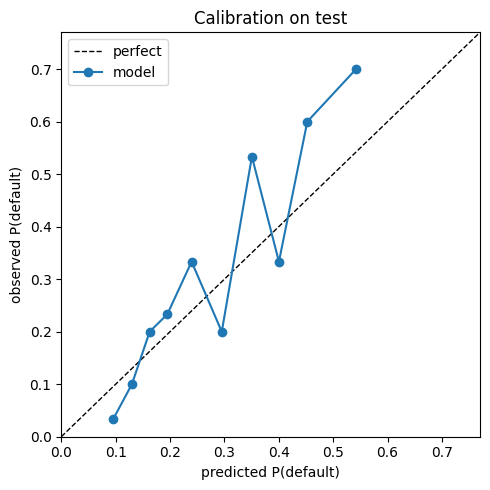

In [12]:
curve = perf.calibration.curve
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.plot(curve.predicted, curve.observed, "o-", label="model")
ax.set_xlabel("predicted P(default)")
ax.set_ylabel("observed P(default)")
ax.set_title("Calibration on test")
ax.legend()
lim = max(curve.predicted.max(), curve.observed.max()) * 1.1
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

## Takeaways

The whole workflow fits on two screens of code:

1. `mc.linear(target=, features=, loss=, penalty=)` — build the spec.
2. `fit_binnings(spec, train)` — supervised bin learning.
3. `mc.solve(spec, train)` — fit, run assumption checks, return a
   frozen `Solution`.
4. `mc.predict(sol, test)` — probabilities on new data.
5. `mc.performance(sol, test, reference=train)` — the bundled
   performance value.

No `fit`/`predict` pair on a stateful estimator; the spec and the
solution are immutable values. See notebook **02** for the temporal
validation, tuning, and bootstrap workflow.